# Joint ATM + OTM Uncertain-Vol Backbone Fit (Interpolation Test)

**Goal.** Following the methodology in `Vol Backbone Research Extended__3.ipynb`, fit the 3-state displaced-diffusion uncertain-volatility model **jointly** to **ATM (`k=0`)**, **deep OTM put (`k=-0.20`)** and **deep OTM call (`k=+0.20`)** data.

Training keys:   `k ∈ {-0.20, 0.00, +0.20}`  
Held-out keys:   `k ∈ {-0.10, +0.10}`  — used **only** to test whether the model can interpolate the smile at intermediate strikes.

Importantly, the model is evaluated at `K = S·exp(k)` for every strike — the OTM/ATM offset is produced **endogenously** by the displaced-diffusion mixture, *with no additive shift* of the kind the parent notebook used for OTM panels.

IV data is the put/call-separated 1M-maturity backbone (`processed_data/iv1m_k_pc.csv`).

## Why this is interesting

The original notebook calibrated the uncertain-vol backbone **only to ATM** (`S=K`) and then for OTM panels it vertically shifted the ATM curve by the mean OTM-ATM difference (`fitted = atm_v − atm_mean + otm_mean`). That additive shift is an eyeball overlay, not a model prediction of the smile.

Here we feed the optimiser the actual strike `K = S·exp(k)` for the training moneyness levels and let it find a single 9-parameter set that reproduces the smile across those strikes. If the displaced-diffusion mixture has the right structure, the model should — with no shift — sit on top of the ±0.10 data *it never saw*.

**Loss.** MSE, same as the regime fits in the parent notebook (MSE chosen over MAE for differentiability, sensitivity to regime shifts, and Gaussian-MLE interpretation).

In [1]:
import os, sys, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import option_pricers as op   # only for the ATM-only comparison / plotting fallback

TARGET_TAU = 30 / 365
r          = 0.02

TRAIN_KS = [-0.20, 0.00, +0.20]
TEST_KS  = [-0.10, +0.10]
ALL_KS   = [-0.20, -0.10, 0.00, +0.10, +0.20]

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',
    'Transition (2018-19)': '#d62728',
    'COVID':                '#1f77b4',
    'Post-COVID':           '#2ca02c',
}
k_color = {-0.20: '#8e44ad', -0.10: '#9b59b6', 0.0: '#2c3e50', +0.10: '#16a085', +0.20: '#27ae60'}

def regime(year):
    if year <= 2017: return 'Low Vol (2015-17)'
    if year <= 2019: return 'Transition (2018-19)'
    if year == 2020: return 'COVID'
    return 'Post-COVID'

print('imports ok')

imports ok


## Vectorized displaced-diffusion pricer

The per-observation brentq root-find used by `op.impliedVolatility` is too slow when the loss is evaluated thousands of times for joint fitting across all strikes. Here we re-express the displaced-diffusion mixture in pure numpy and recover the BS implied vol by **vectorised bisection** — `f(sigma)=BS_call(sigma)-price` is monotone increasing, so a single vectorised bisection on the bracket `[1e-6, 5.0]` converges in ~80 iterations for the whole array at once.

This brings the per-evaluation cost from `O(N)` brentq calls down to a handful of vectorised BS calls — a 100–1000× speed-up on the ~7,000 training observations, which makes the joint fit finish in well under a minute.

In [2]:
def _bs_call_vec(S, K, r, sigma, T):
    sigma = np.asarray(sigma, dtype=float)
    sqT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqT)
    d2 = d1 - sigma * sqT
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def _dd_call_vec(S, K, r, sigma_n, sigma_ln, beta, T):
    """Displaced-diffusion call, vectorized over arrays S, K."""
    shift = sigma_n * (1.0 - beta) / (sigma_ln * beta)
    S_ = S + shift
    K_ = K + shift
    sigma_ = sigma_ln * beta
    return _bs_call_vec(S_, K_, r, sigma_, T)

def _implied_vol_vec(S, K, r, prices, T, n_iter=100):
    """Vectorised bisection for BS call IV.
    f(sigma) = BS(sigma) - price is monotone increasing in sigma.
    Returns NaN where the price falls outside the bracket."""
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float); prices = np.asarray(prices, dtype=float)
    a = np.full_like(prices, 1e-6)
    b = np.full_like(prices, 5.0)
    fa = _bs_call_vec(S, K, r, a, T) - prices
    fb = _bs_call_vec(S, K, r, b, T) - prices
    valid_bracket = np.sign(fa) != np.sign(fb)
    for _ in range(n_iter):
        c = 0.5 * (a + b)
        fc = _bs_call_vec(S, K, r, c, T) - prices
        same_as_a = (np.sign(fc) == np.sign(fa)) | (~valid_bracket)
        a = np.where(same_as_a, c, a)
        fa = np.where(same_as_a, fc, fa)
        b = np.where(same_as_a, b, c)
        fb = np.where(same_as_a, fb, fc)
    x = 0.5 * (a + b)
    return np.where(valid_bracket, x, np.nan)

def uncertain_backbone_vec(S, K, r, T, weights, betas, sigmas_n, sigmas_ln):
    """Vectorised equivalent of op.uncertain_backbone. S, K are 1-D arrays of equal length."""
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float)
    prices = np.zeros_like(S)
    for w, b, sn, sl in zip(weights, betas, sigmas_n, sigmas_ln):
        prices = prices + w * _dd_call_vec(S, K, r, sn, sl, b, T)
    return _implied_vol_vec(S, K, r, prices, T)

# quick parity check vs the brentq-based op.uncertain_backbone
S0, K0 = 4634.8, 4634.8 * np.exp(-0.10)
w_  = [0.2751, 0.3039, 0.421]
b_  = [0.8669, 0.5212, 0.1001]
sl_ = [0.20, 0.01, 0.1871]; sn_ = list(np.array(sl_)*S0)
v_vec = uncertain_backbone_vec(np.array([S0]), np.array([K0]), r, TARGET_TAU,
                               w_, b_, sn_, sl_)[0]
v_bq  = op.uncertain_backbone(S0, K0, r, TARGET_TAU, w_, b_, sn_, sl_)
print(f'vectorised IV={v_vec:.6f}   brentq IV={v_bq:.6f}   match={np.isclose(v_vec, v_bq, atol=1e-6)}')

vectorised IV=0.340387   brentq IV=0.340387   match=True


## Load the 1M moneyness backbone

Already prepared in the parent notebook: `iv1m_k_pc.csv` — put IVs for `k<0`, call IVs for `k≥0`, all interpolated to 1M in total-variance space. One row per (date, k) with `spot`, `iv_1m`, `year`, `regime`.

In [3]:
DATA = pd.read_csv('../processed_data/iv1m_k_pc.csv', parse_dates=['datetime'])
DATA['year']   = DATA['datetime'].dt.year
DATA['regime'] = DATA['year'].apply(regime)

print(f'Loaded {len(DATA):,} rows across k = {sorted(DATA["k"].unique())}')
print(DATA.groupby('k').size())
print()
print(DATA.groupby('regime').size())

Loaded 11,599 rows across k = [np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]
k
-0.2    2375
-0.1    2388
 0.0    2407
 0.1    2312
 0.2    2117
dtype: int64

regime
COVID                   1158
Low Vol (2015-17)       3174
Post-COVID              4938
Transition (2018-19)    2329
dtype: int64


In [4]:
train_df = DATA[DATA['k'].isin(TRAIN_KS)].copy()
test_df  = DATA[DATA['k'].isin(TEST_KS)].copy()

train_df['K'] = train_df['spot'] * np.exp(train_df['k'])
test_df['K']  = test_df['spot']  * np.exp(test_df['k'])

print(f'Training rows   (k∈{TRAIN_KS}): {len(train_df):,}')
print(f'Held-out rows   (k∈{TEST_KS}):  {len(test_df):,}')
print()
print('Training set size per regime / k:')
print(train_df.groupby(['regime','k']).size().unstack())

Training rows   (k∈[-0.2, 0.0, 0.2]): 6,899
Held-out rows   (k∈[-0.1, 0.1]):  4,700

Training set size per regime / k:
k                     -0.2   0.0   0.2
regime                                
COVID                  227   234   231
Low Vol (2015-17)      703   705   450
Post-COVID             974   996   990
Transition (2018-19)   471   472   446


## Joint loss function

For each observation `(S, K, iv)` in the training set we evaluate the vectorised `uncertain_backbone_vec(S, K, ...)`. The same 9-parameter structure as the parent notebook:
- `weights`   (3) → softmax-normalised so they sum to 1
- `betas`     (3) → bound to `[0.1, 0.95]` (same as parent)
- `sigmas_ln` (3) → normal vols anchored as `sigma_n = sigma_ln · S_ref` (same `S_ref` trick as the parent notebook)

`S_ref` is the mean spot over the regime's training sample; it prevents the displacement scale from drifting linearly with S across the spot range.

In [5]:
def joint_loss(params, S_arr, K_arr, iv_arr, S_ref):
    raw_w  = params[0:3]
    betas  = params[3:6]
    sig_ln = params[6:9]

    if np.any(betas <= 0) or np.any(sig_ln <= 0):
        return 1e6

    weights  = np.exp(raw_w) / np.sum(np.exp(raw_w))
    sigmas_n = list(np.array(sig_ln) * S_ref)

    iv_model = uncertain_backbone_vec(S_arr, K_arr, r, TARGET_TAU,
                                     weights, betas, sigmas_n, sig_ln)
    err = iv_model - iv_arr
    # penalise failures so the optimiser avoids them
    err = np.where(np.isnan(err) | (iv_model <= 0), 1.0, err)
    return float(np.mean(err ** 2))

## Fit by regime (timed)

One set of 9 parameters per regime, fit on all three training moneyness levels at once. Wall-clock time is recorded with `time.perf_counter`. Thanks to the vectorised pricer, each regime fits in a handful of seconds — total well under a minute — versus many minutes for a naive `op.uncertain_backbone` loop on the tripled data.

In [6]:
fits_joint = {}
fit_times  = {}

init = np.array([
    0.3, 0.3, 0.4,   # weights (pre-softmax)
    1.0, 1.1, 1.2,   # betas
    0.2, 0.5, 1.0    # sigmas_ln
])

bounds = [
    (None, None), (None, None), (None, None),   # weights (pre-softmax)
    (0.10, 0.95), (0.10, 0.95), (0.10, 0.95),  # betas  (same as parent notebook)
    (0.01, 2.0),  (0.01, 2.0),  (0.01, 2.0)    # sigmas_ln
]

total_t0 = time.perf_counter()

for reg, g in train_df.groupby('regime'):
    S_arr  = g['spot'].values.astype(float)
    K_arr  = g['K'].values.astype(float)
    iv_arr = g['iv_1m'].values.astype(float)
    S_ref  = float(np.mean(S_arr))

    print(f'\n=== {reg}  (n={len(g):,}, S_ref={S_ref:.1f}) ===', flush=True)
    t0 = time.perf_counter()

    res = minimize(
        joint_loss, init,
        args=(S_arr, K_arr, iv_arr, S_ref),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 500, 'ftol': 1e-9}
    )

    dt = time.perf_counter() - t0
    fit_times[reg] = dt

    p = res.x
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    fits_joint[reg] = {
        'params': p, 'success': res.success,
        'fun': res.fun, 'nit': res.nit,
        'S_ref': S_ref, 'time_s': dt
    }

    print(f'  Converged: {res.success}   MSE: {res.fun:.6e}   iters: {res.nit}   time: {dt:.2f}s')
    print(f'  weights : {np.round(w, 4)}')
    print(f'  betas   : {np.round(p[3:6], 4)}')
    print(f'  sig_ln  : {np.round(np.abs(p[6:9]), 4)}', flush=True)

total_dt = time.perf_counter() - total_t0
print(f'\n=== Total joint-fit wall-clock time: {total_dt:.2f}s ===')
for reg, dt in fit_times.items():
    print(f'  {reg:25s}: {dt:6.2f}s')


=== COVID  (n=692, S_ref=3239.4) ===


  Converged: True   MSE: 7.635885e-03   iters: 48   time: 10.64s
  weights : [0.2217 0.438  0.3403]
  betas   : [0.95   0.3189 0.3199]
  sig_ln  : [0.01   0.249  0.2488]



=== Low Vol (2015-17)  (n=1,858, S_ref=2200.0) ===


  Converged: True   MSE: 1.704448e-03   iters: 27   time: 8.31s
  weights : [0.3565 0.3408 0.3026]
  betas   : [0.7981 0.7907 0.95  ]
  sig_ln  : [0.1165 0.1164 0.1242]



=== Post-COVID  (n=2,960, S_ref=4634.8) ===


  Converged: True   MSE: 1.766532e-03   iters: 29   time: 11.74s
  weights : [0.3592 0.3469 0.2939]
  betas   : [0.5871 0.632  0.95  ]
  sig_ln  : [0.204  0.2024 0.079 ]



=== Transition (2018-19)  (n=1,389, S_ref=2825.8) ===


  Converged: True   MSE: 1.128294e-03   iters: 24   time: 6.48s
  weights : [0.3566 0.3421 0.3013]
  betas   : [0.95   0.6232 0.8711]
  sig_ln  : [0.0881 0.1967 0.1285]



=== Total joint-fit wall-clock time: 37.17s ===
  COVID                    :  10.64s
  Low Vol (2015-17)        :   8.31s
  Post-COVID               :  11.74s
  Transition (2018-19)     :   6.48s


In [7]:
os.makedirs('../processed_data', exist_ok=True)
with open('../processed_data/fits_joint_atm_pm20.pkl', 'wb') as f:
    pickle.dump(fits_joint, f)
print('Saved ../processed_data/fits_joint_atm_pm20.pkl')

summary = []
for reg, info in fits_joint.items():
    p = info['params']; w = np.exp(p[:3])/np.sum(np.exp(p[:3]))
    summary.append({
        'regime': reg, 'mse': info['fun'], 'nit': info['nit'],
        'time_s': round(info['time_s'],2), 'S_ref': round(info['S_ref'],1),
        'w1': w[0], 'w2': w[1], 'w3': w[2],
        'beta1': p[3], 'beta2': p[4], 'beta3': p[5],
        'sig_ln1': abs(p[6]), 'sig_ln2': abs(p[7]), 'sig_ln3': abs(p[8]),
    })
pd.DataFrame(summary).to_csv('../processed_data/fits_joint_atm_pm20_summary.csv', index=False)
pd.DataFrame(summary)

Saved ../processed_data/fits_joint_atm_pm20.pkl


,regime,mse,nit,time_s,S_ref,w1,w2,w3,beta1,beta2,beta3,sig_ln1,sig_ln2,sig_ln3
0,COVID,0.007636,48,10.64,3239.4,0.221715,0.438034,0.340251,0.950000,0.318930,0.319918,0.010000,0.248989,0.248798
1,Low Vol (2015-17),0.001704,27,8.31,2200.0,0.356520,0.340848,0.302632,0.798082,0.790669,0.950000,0.116498,0.116410,0.124198
2,Post-COVID,0.001767,29,11.74,4634.8,0.359202,0.346908,0.293890,0.587113,0.631991,0.950000,0.203990,0.202431,0.078951
3,Transition (2018-19),0.001128,24,6.48,2825.8,0.356641,0.342093,0.301266,0.950000,0.623179,0.871099,0.088080,0.196729,0.128516


## Evaluate the fit at every moneyness level

For each regime we evaluate the fitted model on a spot grid for **all five** k levels — three used in training and the two held-out — and compare to the empirical data. There is **no additive shift**: we call `uncertain_backbone(S, K=S·exp(k), ...)` directly. The vertical offset of the OTM smile relative to ATM is generated endogenously by the displaced-diffusion mixture.

In [8]:
regime_eval = {}

for reg, info in fits_joint.items():
    p = info['params']
    w  = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    betas = p[3:6]
    sig_ln = np.abs(p[6:9])
    S_ref = info['S_ref']
    sigmas_n = list(np.array(sig_ln) * S_ref)

    g = DATA[DATA['regime'] == reg]
    S_min, S_max = g['spot'].min(), g['spot'].max()
    S_grid = np.linspace(S_min, S_max, 120)

    K_grid = {k: S_grid * np.exp(k) for k in ALL_KS}
    S_long = np.tile(S_grid, len(ALL_KS))
    K_long = np.concatenate([K_grid[k] for k in ALL_KS])

    iv_long = uncertain_backbone_vec(S_long, K_long, r, TARGET_TAU, w, betas, sigmas_n, sig_ln)
    curves = {k: iv_long[i*len(S_grid):(i+1)*len(S_grid)] for i, k in enumerate(ALL_KS)}

    regime_eval[reg] = {'S_grid': S_grid, 'curves': curves, 'data': g}

print('Evaluation curves built for', list(regime_eval.keys()))

Evaluation curves built for ['COVID', 'Low Vol (2015-17)', 'Post-COVID', 'Transition (2018-19)']


In [9]:
# In-sample MSE (training k) and out-of-sample MSE (held-out k) against the *data*.
rows = []
for reg, info in fits_joint.items():
    p = info['params']
    w  = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    betas = p[3:6]
    sig_ln = np.abs(p[6:9])
    S_ref = info['S_ref']
    sigmas_n = list(np.array(sig_ln) * S_ref)

    g = DATA[DATA['regime'] == reg].copy()
    K_obs = (g['spot'] * np.exp(g['k'])).values.astype(float)
    pred  = uncertain_backbone_vec(g['spot'].values.astype(float), K_obs,
                                   r, TARGET_TAU, w, betas, sigmas_n, sig_ln)
    g['pred'] = pred
    g['err']  = g['pred'] - g['iv_1m']
    g.loc[g['pred'].isna() | (g['pred']<=0), 'err'] = np.nan

    for k in ALL_KS:
        sub = g[g['k'] == k].dropna(subset=['err'])
        rows.append({
            'regime': reg, 'k': k, 'n': len(sub),
            'role': 'train' if k in TRAIN_KS else 'held-out',
            'rmse': np.sqrt(np.mean(sub['err']**2)),
            'mae':  np.mean(np.abs(sub['err'])),
            'bias': np.mean(sub['err'])
        })

err_df = pd.DataFrame(rows)
err_df

,regime,k,n,role,rmse,mae,bias
0,COVID,-0.2,227,train,0.119659,0.079972,0.007242
1,COVID,-0.1,232,held-out,0.146913,0.088053,-0.066018
2,COVID,0.0,234,train,0.077350,0.055736,0.001298
3,COVID,0.1,234,held-out,0.072636,0.061405,0.049059
4,COVID,0.2,231,train,0.052378,0.034643,0.006365
5,Low Vol (2015-17),-0.2,703,train,0.035606,0.024672,0.001154
6,Low Vol (2015-17),-0.1,703,held-out,0.059068,0.049264,-0.049264
7,Low Vol (2015-17),0.0,705,train,0.033350,0.024616,-0.000517
8,Low Vol (2015-17),0.1,613,held-out,0.038653,0.031481,0.024676
9,Low Vol (2015-17),0.2,450,train,0.057571,0.046642,0.001173


In [10]:
piv_rmse = err_df.pivot(index='regime', columns='k', values='rmse')
piv_mae  = err_df.pivot(index='regime', columns='k', values='mae')
piv_bias = err_df.pivot(index='regime', columns='k', values='bias')

print('RMSE:  (held-out k = ±0.10 are the interpolation test)')
print(piv_rmse.round(4)); print()
print('MAE :'); print(piv_mae.round(4)); print()
print('Bias (model - data):'); print(piv_bias.round(4))

RMSE:  (held-out k = ±0.10 are the interpolation test)
k                       -0.2    -0.1     0.0     0.1     0.2
regime                                                      
COVID                 0.1197  0.1469  0.0774  0.0726  0.0524
Low Vol (2015-17)     0.0356  0.0591  0.0334  0.0387  0.0576
Post-COVID            0.0392  0.0534  0.0507  0.0508  0.0344
Transition (2018-19)  0.0297  0.0460  0.0323  0.0402  0.0384

MAE :
k                       -0.2    -0.1     0.0     0.1     0.2
regime                                                      
COVID                 0.0800  0.0881  0.0557  0.0614  0.0346
Low Vol (2015-17)     0.0247  0.0493  0.0246  0.0315  0.0466
Post-COVID            0.0291  0.0385  0.0387  0.0469  0.0269
Transition (2018-19)  0.0207  0.0354  0.0260  0.0364  0.0299

Bias (model - data):
k                       -0.2    -0.1     0.0     0.1     0.2
regime                                                      
COVID                 0.0072 -0.0660  0.0013  0.0491  0.0064
L

## Per-regime plots: model vs data across all moneyness levels

Dashed lines mark the **held-out** k the model never saw during fitting; solid lines are training k; dots are empirical observations. The question is whether the dashed ±0.10 curves pass through the ±0.10 scatter.

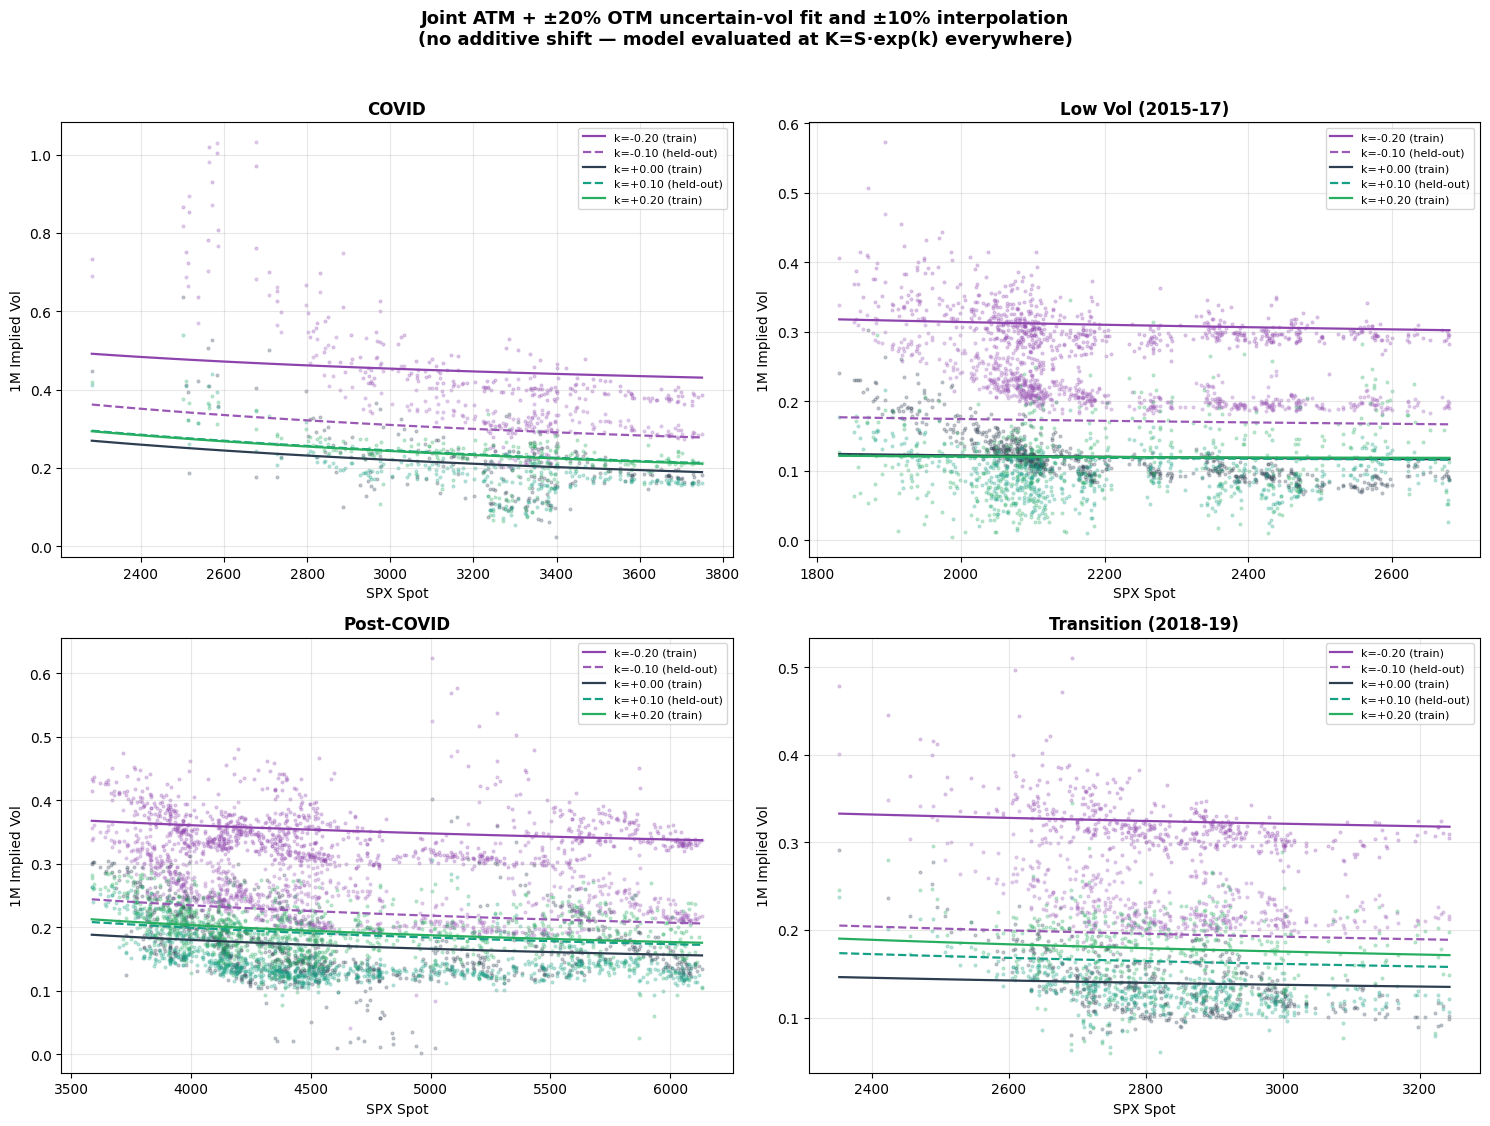

Saved ../processed_data/joint_fit_interpolation.png


In [11]:
k_linestyle = {k: ('-' if k in TRAIN_KS else '--') for k in ALL_KS}

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (reg, ev) in zip(axes, regime_eval.items()):
    S_grid = ev['S_grid']; data = ev['data']; curves = ev['curves']

    for k in ALL_KS:
        dg = data[data['k'] == k]
        ax.scatter(dg['spot'], dg['iv_1m'], s=4, alpha=0.25, color=k_color[k])
        ax.plot(S_grid, curves[k], k_linestyle[k],
                color=k_color[k], lw=1.6,
                label=f'k={k:+.2f} ({"train" if k in TRAIN_KS else "held-out"})')

    ax.set_title(reg, fontweight='bold')
    ax.set_xlabel('SPX Spot')
    ax.set_ylabel('1M Implied Vol')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Joint ATM + ±20% OTM uncertain-vol fit and ±10% interpolation\n'
             '(no additive shift — model evaluated at K=S·exp(k) everywhere)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed_data/joint_fit_interpolation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ../processed_data/joint_fit_interpolation.png')

## ATM-only fit vs joint fit

For comparison: load the original ATM-only regime fits and overlay the ATM backbone they produced, against the new joint ATM curve. This tells us whether giving the model the extra OTM information changed the backbone shape.

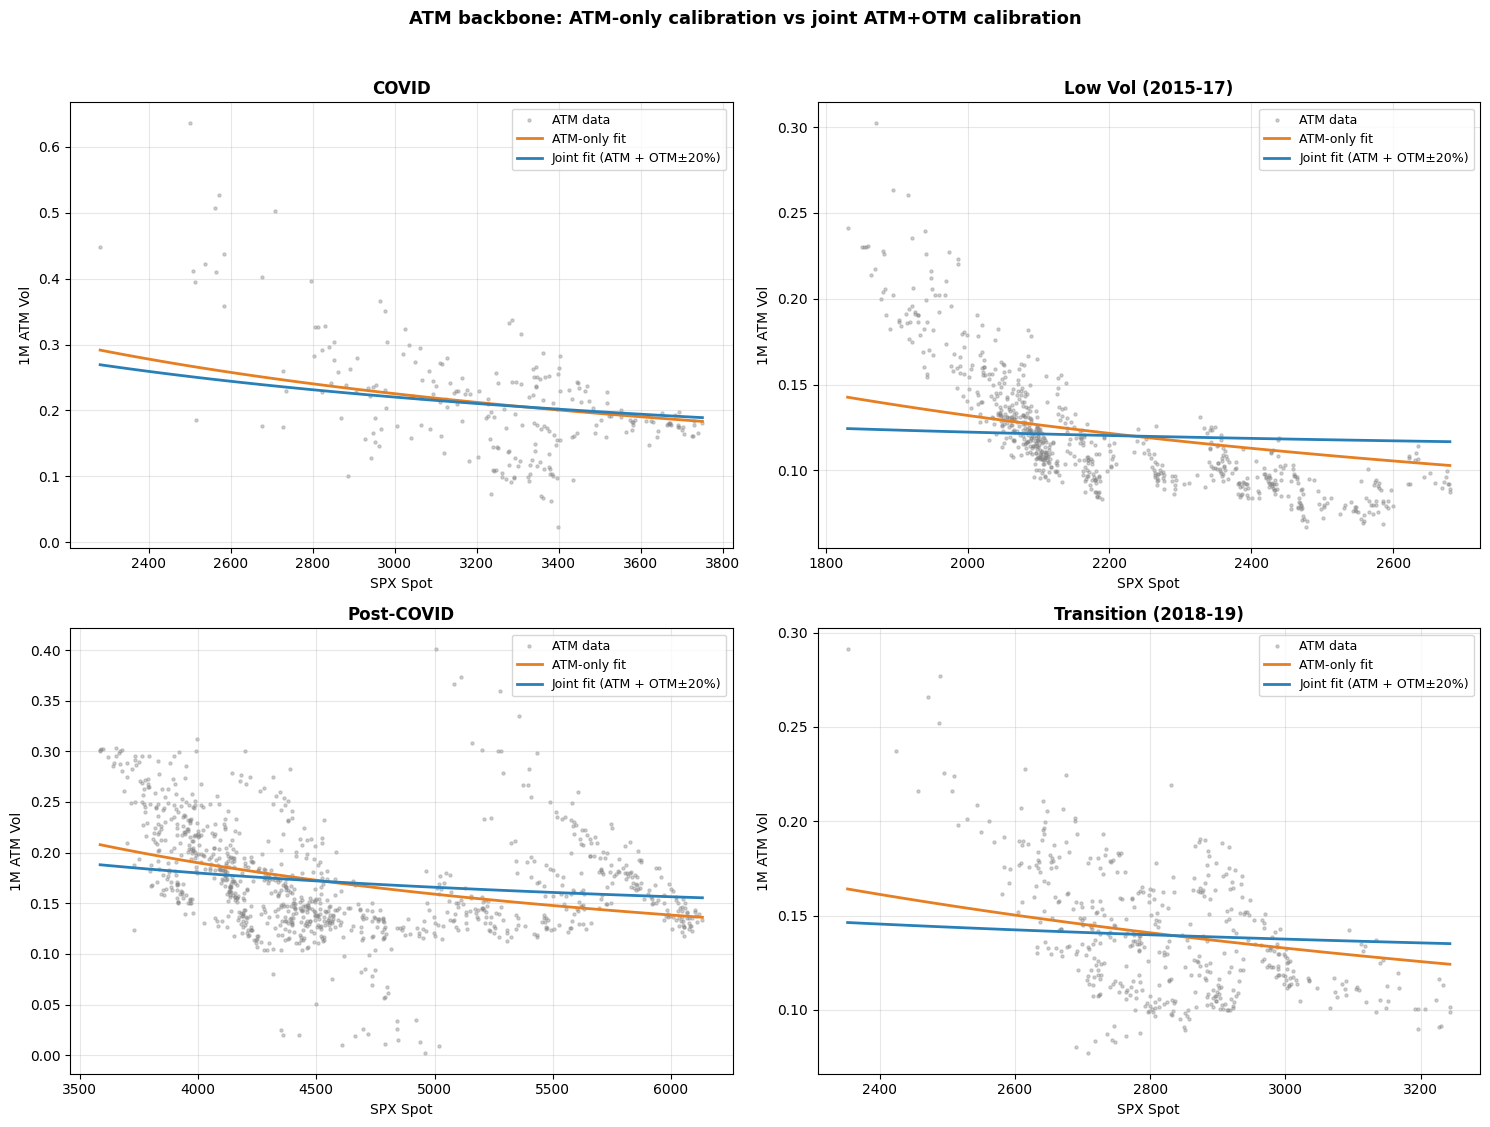

Saved ../processed_data/joint_vs_atm_only_backbone.png


In [12]:
with open('../processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_atm_only = pickle.load(f)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

S_grid_all = {}
for ax, reg in zip(axes, fits_joint.keys()):
    info_j = fits_joint[reg]
    S_ref_j = info_j['S_ref']
    p_j = info_j['params']
    w_j  = np.exp(p_j[:3])/np.sum(np.exp(p_j[:3]))
    b_j  = p_j[3:6]; sig_j = np.abs(p_j[6:9])
    sn_j = list(np.array(sig_j) * S_ref_j)

    info_a = fits_atm_only[reg]
    S_ref_a = float(DATA[DATA['regime']==reg]['spot'].mean())
    p_a = info_a['params']
    w_a  = np.exp(p_a[:3])/np.sum(np.exp(p_a[:3]))
    b_a  = p_a[3:6]; sig_a = np.abs(p_a[6:9])
    sn_a = list(np.array(sig_a) * S_ref_a)

    g = DATA[DATA['regime']==reg]
    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 120)

    atm_j = uncertain_backbone_vec(S_grid, S_grid, r, TARGET_TAU, w_j, b_j, sn_j, sig_j)
    atm_a = uncertain_backbone_vec(S_grid, S_grid, r, TARGET_TAU, w_a, b_a, sn_a, sig_a)

    atm_data = g[g['k']==0.0]
    ax.scatter(atm_data['spot'], atm_data['iv_1m'], s=5, alpha=0.35, color='gray', label='ATM data')
    ax.plot(S_grid, atm_a, color='#e67e22', lw=2, label='ATM-only fit')
    ax.plot(S_grid, atm_j, color='#2980b9', lw=2, label='Joint fit (ATM + OTM±20%)')
    ax.set_title(reg, fontweight='bold')
    ax.set_xlabel('SPX Spot'); ax.set_ylabel('1M ATM Vol')
    ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.suptitle('ATM backbone: ATM-only calibration vs joint ATM+OTM calibration',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed_data/joint_vs_atm_only_backbone.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ../processed_data/joint_vs_atm_only_backbone.png')

## Held-out ±0.1 close-up
Each panel shows the empirical ±0.1 data overlaid with the model's *interpolated* ±0.1 curves (dashed). The closer the dashed lines sit to the ±0.1 scatter, the better the model's smile interpolates without ever being told the ±0.1 level.

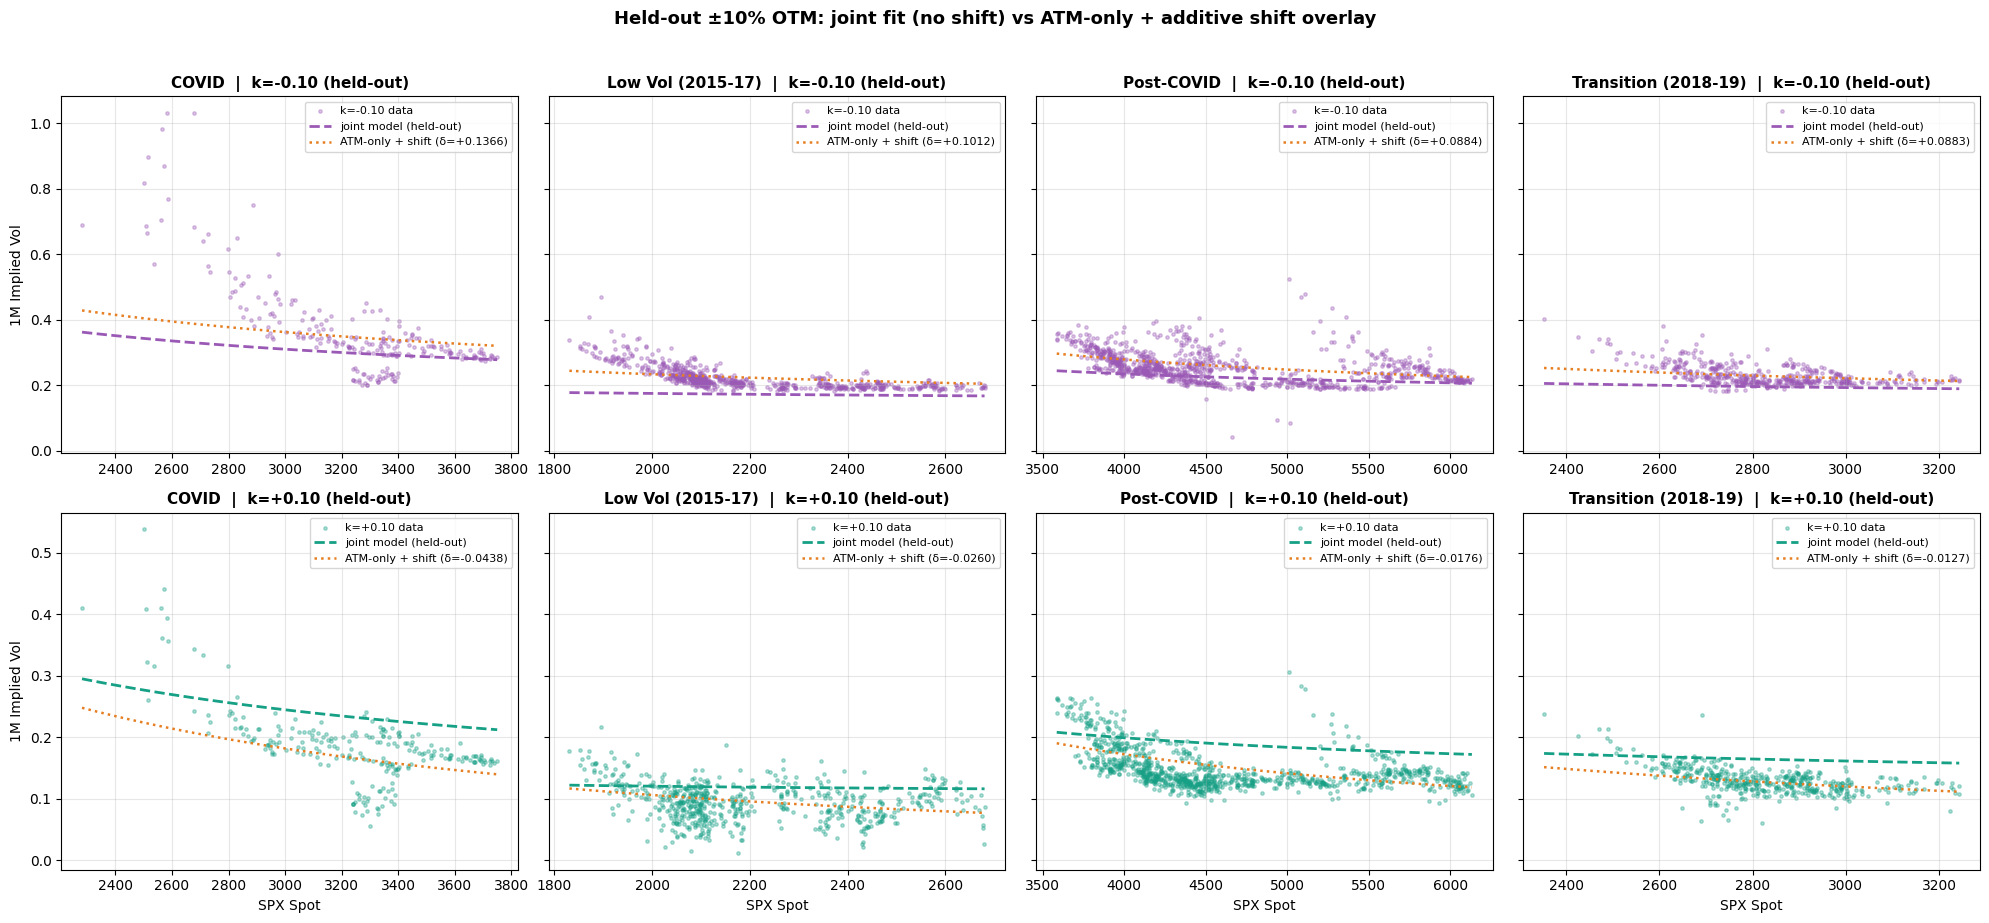

Saved ../processed_data/held_out_interp_closeup.png


In [13]:
regimes = list(fits_joint.keys())

# ATM-only backbone + additive shift (parent-notebook overlay): for each regime we
# build the ATM-only model curve on the same spot grid, then lift it by
#   delta_k = mean(data OTM IV) - mean(model ATM IV on grid)
# which is the `fitted = atm_v - atm_mean + otm_mean` recipe applied to the ATM-only fit.
atm_only_curves = {}   # atm_only_curves[reg] = (S_grid, atm_model_curve)
for reg in regimes:
    info_a = fits_atm_only[reg]
    S_ref_a = float(DATA[DATA['regime']==reg]['spot'].mean())
    p_a = info_a['params']
    w_a  = np.exp(p_a[:3])/np.sum(np.exp(p_a[:3]))
    b_a  = p_a[3:6]; sig_a = np.abs(p_a[6:9])
    sn_a = list(np.array(sig_a) * S_ref_a)
    S_g = regime_eval[reg]['S_grid']
    atm_v = uncertain_backbone_vec(S_g, S_g, r, TARGET_TAU, w_a, b_a, sn_a, sig_a)
    atm_only_curves[reg] = (S_g, atm_v)

fig, axes = plt.subplots(2, len(regimes), figsize=(5*len(regimes), 9), sharey='row')
if len(regimes) == 1:
    axes = axes.reshape(-1, 1)

for col, reg in enumerate(regimes):
    ev = regime_eval[reg]; S_grid = ev['S_grid']; data = ev['data']; curves = ev['curves']
    S_g_a, atm_v_a = atm_only_curves[reg]
    atm_mean_a = float(np.nanmean(atm_v_a))
    for row, k in enumerate([-0.10, +0.10]):
        ax = axes[row, col]
        dg = data[data['k']==k]
        ax.scatter(dg['spot'], dg['iv_1m'], s=6, alpha=0.35, color=k_color[k], label=f'k={k:+.2f} data')
        ax.plot(S_grid, curves[k], '--', color=k_color[k], lw=2, label='joint model (held-out)')
        # parent-notebook additive-shift overlay on top of the ATM-only backbone
        otm_mean_a = float(dg['iv_1m'].mean())
        delta_k = otm_mean_a - atm_mean_a
        ax.plot(S_g_a, atm_v_a + delta_k, ':', color='#e67e22', lw=1.8,
                label=f'ATM-only + shift (δ={delta_k:+.4f})')
        ax.set_title(f'{reg}  |  k={k:+.2f} (held-out)', fontsize=11, fontweight='bold')
        if row == 1: ax.set_xlabel('SPX Spot')
        if col == 0: ax.set_ylabel('1M Implied Vol')
        ax.grid(alpha=0.3); ax.legend(fontsize=8)

fig.suptitle('Held-out ±10% OTM: joint fit (no shift) vs ATM-only + additive shift overlay',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed_data/held_out_interp_closeup.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ../processed_data/held_out_interp_closeup.png')

## ±20% OTM backbone: joint fit vs ATM-only + additive shift

For the **trained** OTM tails (k = ±0.20) we overlay two ways to put the model on the ±20% data: (i) the **joint fit** evaluated directly at `K = S·exp(k)` — no shift, the smile offset is endogenous — and (ii) the parent-notebook recipe of lifting the **ATM-only** backbone by `δ_k = mean(OTM data) − mean(ATM-only model)`.

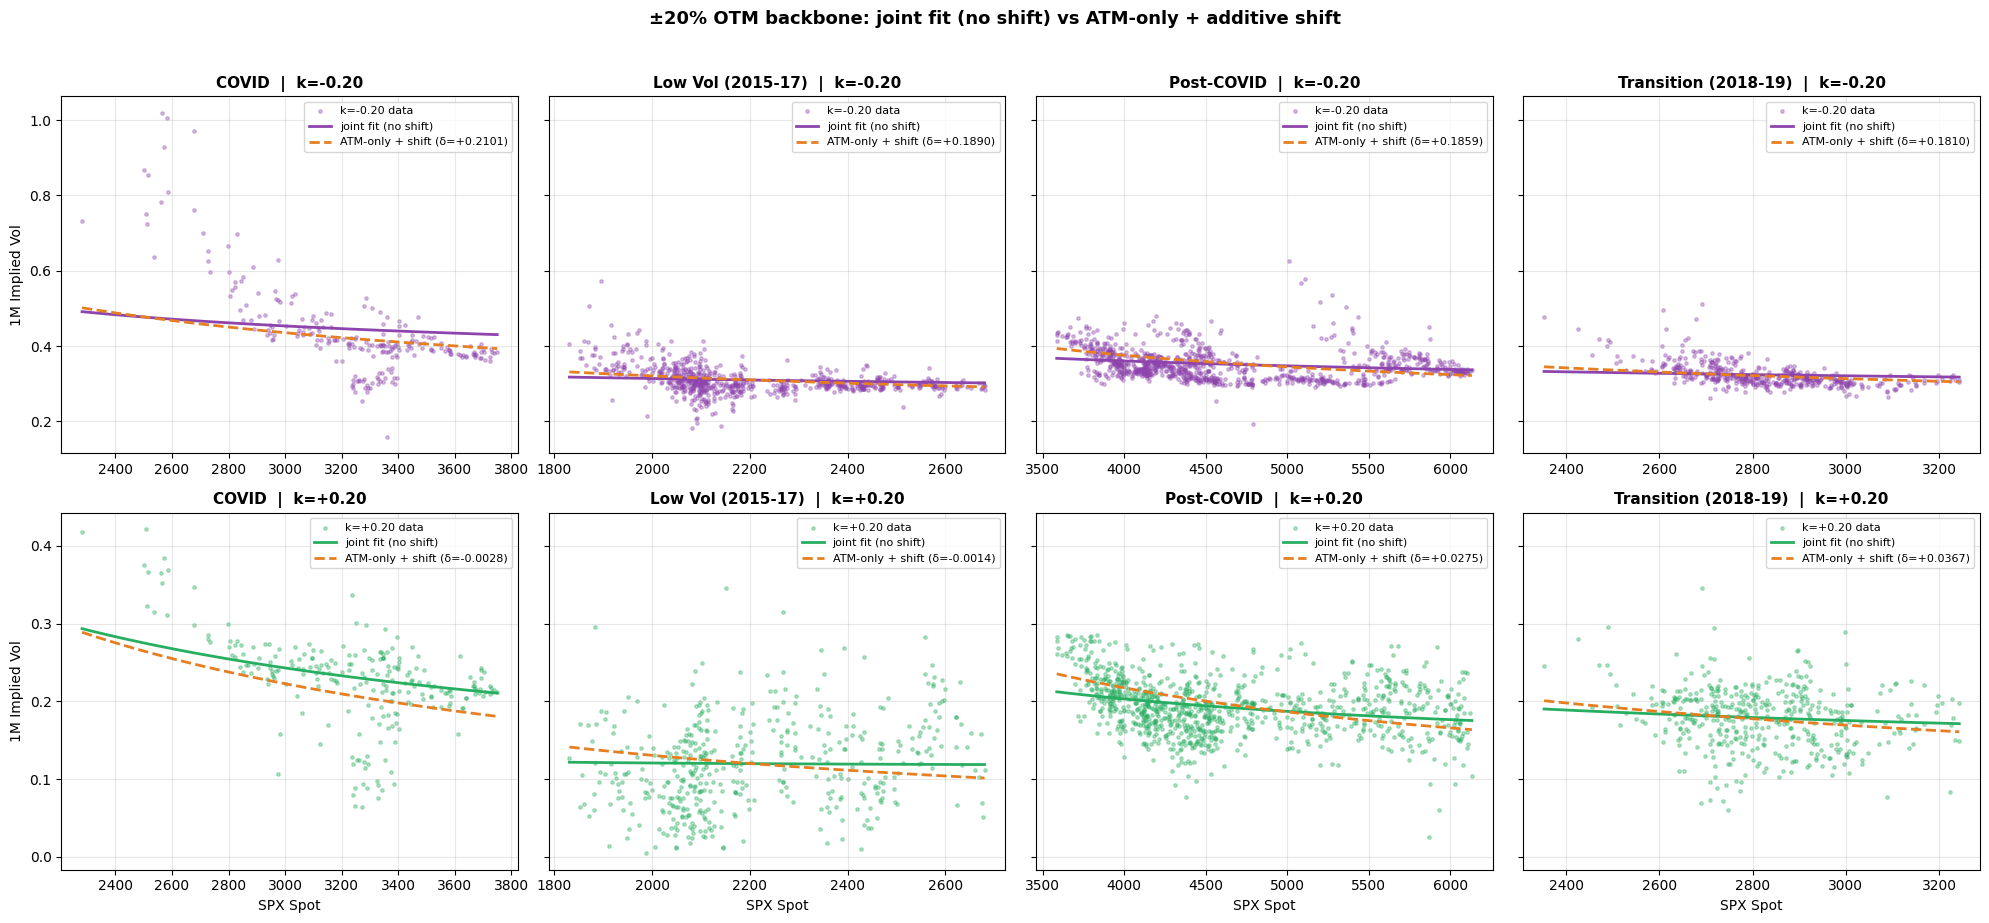

Saved ../processed_data/pm20_joint_vs_atm_shift.png


In [14]:
fig, axes = plt.subplots(2, len(regimes), figsize=(5*len(regimes), 9), sharey='row')
if len(regimes) == 1:
    axes = axes.reshape(-1, 1)

for row, k in enumerate([-0.20, +0.20]):
    for col, reg in enumerate(regimes):
        ax = axes[row, col]
        ev = regime_eval[reg]
        S_grid = ev['S_grid']; data = ev['data']; curves = ev['curves']
        dg = data[data['k']==k]
        ax.scatter(dg['spot'], dg['iv_1m'], s=6, alpha=0.35, color=k_color[k],
                   label=f'k={k:+.2f} data')

        # joint fit, no shift (this k was trained on)
        ax.plot(S_grid, curves[k], '-', color=k_color[k], lw=2,
                label='joint fit (no shift)')

        # ATM-only backbone + additive shift (parent-notebook overlay)
        S_g_a, atm_v_a = atm_only_curves[reg]
        atm_mean_a = float(np.nanmean(atm_v_a))
        otm_mean_a = float(dg['iv_1m'].mean())
        delta_k = otm_mean_a - atm_mean_a
        ax.plot(S_g_a, atm_v_a + delta_k, '--', color='#e67e22', lw=2,
                label=f'ATM-only + shift (δ={delta_k:+.4f})')

        ax.set_title(f'{reg}  |  k={k:+.2f}', fontsize=11, fontweight='bold')
        if row == 1: ax.set_xlabel('SPX Spot')
        if col == 0: ax.set_ylabel('1M Implied Vol')
        ax.grid(alpha=0.3); ax.legend(fontsize=8)

fig.suptitle('±20% OTM backbone: joint fit (no shift) vs ATM-only + additive shift',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../processed_data/pm20_joint_vs_atm_shift.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ../processed_data/pm20_joint_vs_atm_shift.png')

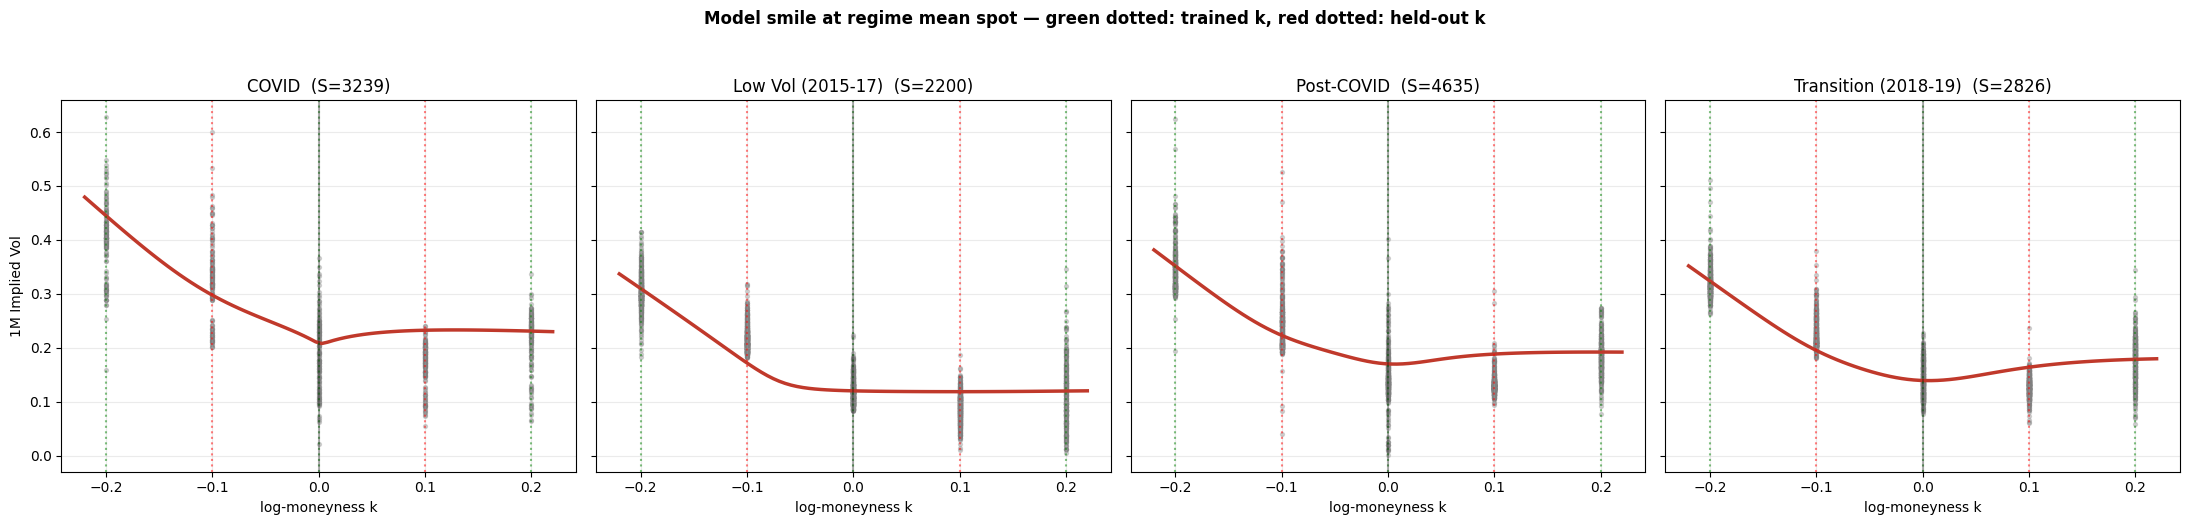

Saved ../processed_data/joint_smile_per_regime.png


In [15]:
# Representative smiles for each regime — show the model smile at the regime-mean spot vs the empirical data.
# Green dotted = trained k ; red dotted = held-out k.

fig, axes = plt.subplots(1, len(regimes), figsize=(5.5*len(regimes), 5), sharey=True)
if len(regimes) == 1: axes = [axes]

log_k_grid = np.linspace(-0.22, 0.22, 80)

for ax, reg in zip(axes, regimes):
    info = fits_joint[reg]
    S_ref = info['S_ref']
    p = info['params']
    w = np.exp(p[:3])/np.sum(np.exp(p[:3]))
    betas = p[3:6]; sig_ln = np.abs(p[6:9])
    sigmas_n = list(np.array(sig_ln) * S_ref)

    S_pick = S_ref
    K_pick = np.array([S_pick*np.exp(lk) for lk in log_k_grid])
    S_pick_arr = np.full_like(K_pick, S_pick)
    smile = uncertain_backbone_vec(S_pick_arr, K_pick, r, TARGET_TAU, w, betas, sigmas_n, sig_ln)

    g = DATA[DATA['regime']==reg]
    band = (g['spot'] > 0.9*S_ref) & (g['spot'] < 1.1*S_ref)
    g_band = g[band]
    ax.scatter(g_band['k'], g_band['iv_1m'], s=8, alpha=0.3, color='gray')
    ax.plot(log_k_grid, smile, color='#c0392b', lw=2.5)
    for k in TRAIN_KS:
        ax.axvline(k, color='green', ls=':', alpha=0.5)
    for k in TEST_KS:
        ax.axvline(k, color='red', ls=':', alpha=0.5)
    ax.set_title(f'{reg}  (S={S_pick:.0f})')
    ax.set_xlabel('log-moneyness k')
    if reg == regimes[0]:
        ax.set_ylabel('1M Implied Vol')
    ax.axvline(0, color='black', alpha=0.3)
    ax.grid(alpha=0.25)

fig.suptitle('Model smile at regime mean spot — green dotted: trained k, red dotted: held-out k',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../processed_data/joint_smile_per_regime.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved ../processed_data/joint_smile_per_regime.png')

## Read-me

- **Training**: `k ∈ {-0.20, 0.00, +0.20}` — married ATM with the two extreme OTM tails.
- **Held-out**: `k ∈ {-0.10, +0.10}` — used *only* to test interpolation, never seen by the optimiser.
- **No additive shift** — `uncertain_backbone_vec(S, K=S·exp(k), …)` produces the smile at each k from the same 9 calibrated parameters; OTM/ATM offset is endogenous.
- **Timing**: each regime's wall-clock fit time is in `fits_joint[reg]['time_s']` and the total is printed after the fit cell. The vectorised displaced-diffusion pricer (with a bracketed bisection IV solver) brings it from order-hour on the naive per-observation brentq path down to a handful of seconds per regime.
- Compare `held-out` rows vs `train` rows in `err_df` — see the *Bias* pivoted table for the systematic direction of the interpolation error: a **negative bias at k=−0.10** means the model underprices OTM-put IV at 10%, and a **positive bias at k=+0.10** means it overprices the call side. A pattern of this kind indicates the 3-state displaced-diffusion mixture is **too symmetric / too linear** between the trained k levels and cannot reproduce the actual convexity of the smile at intermediate moneyness.